# Slice Duration vs Survival Probability

Simulates the velocity-selection slice pulse and plots the fraction of atoms that survive (i.e. are found in the excited state after the slice) as a function of slice duration.

Slice duration is swept log-spaced from 0.01x to 100x the spectroscopy pulse duration.

In [1]:
import sys

import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from tqdm import tqdm

import sys
sys.path.insert(0, '..')

import lmt_sim.version_info as vs
from lmt_sim.lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    pulse_interaction_in_borde_representation,
    calculate_ground_and_excited_probabilities,
    K_WAVEVECTOR,
    TRANSITION_FREQUENCY,
)

%matplotlib inline

In [3]:
np.random.seed(42)

T_SPECTROSCOPY = 45e-6

RABI_FREQ_SPECTROSCOPY = 1.0 / (2.0 * T_SPECTROSCOPY)

MASS_ATOM = constants.atomic_mass * 87.0
TRANSITION_WAVELENGTH = 698e-9

TEMPERATURE = 200e-9
N_ATOMS = 300

N_SLICE_POINTS = 100

# Single-photon recoil frequency
F_RECOIL = constants.h / (MASS_ATOM * TRANSITION_WAVELENGTH**2)
BASE_DETUNING_HZ = F_RECOIL / 2  # Same detuning as MZ

In [4]:
sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0.0, sigma_v, size=N_ATOMS)

# Slice durations log-spaced from 0.01x to 100x the spectroscopy pulse
slice_durations = np.logspace(
    np.log10(0.01 * T_SPECTROSCOPY),
    np.log10(100.0 * T_SPECTROSCOPY),
    N_SLICE_POINTS,
)
slice_durations_over_spectroscopy = slice_durations / T_SPECTROSCOPY

print(f"sigma_v = {sigma_v:.3e} m/s")
print(
    f"Slice duration range: {slice_durations[0] * 1e6:.3f} us to "
    f"{slice_durations[-1] * 1e6:.1f} us"
)

sigma_v = 4.372e-03 m/s
Slice duration range: 0.450 us to 4500.0 us


In [5]:
def calc_slice_survival_probability(
    slice_pulse_duration,
    detuning_hz=0.0,
    initial_velocity_z=0.0,
):
    """Returns the excited-state probability after the velocity-selection slice pulse.

    This is the probability that an atom survives the slice (is not cleared out).
    The slice pulse Rabi frequency is calibrated for a pi pulse at this duration.
    """
    rabi_freq_slice = 1.0 / (2.0 * slice_pulse_duration)

    state = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    omega_laser = 2.0 * np.pi * (TRANSITION_FREQUENCY + detuning_hz)

    state = transform_state_vector(
        state,
        omega_laser=omega_laser,
        t=0.0,
        z=0.0,
        vz=initial_velocity_z,
        inverse=False,
    )

    state = pulse_interaction_in_borde_representation(
        state,
        pulse_detuning=detuning_hz,
        t_pulse=slice_pulse_duration,
        pulse_rabi_freq=rabi_freq_slice,
        pulse_phase=0.0,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )

    state = transform_state_vector(
        state,
        omega_laser=omega_laser,
        t=slice_pulse_duration,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    _ground_prob, excited_prob = calculate_ground_and_excited_probabilities(state)

    return excited_prob


In [6]:
# survival_traces[atom, slice_point] = excited probability after slice for that atom
survival_traces = np.empty((N_ATOMS, N_SLICE_POINTS))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    for ind_slice, slice_duration in enumerate(slice_durations):
        survival_traces[ind_atom, ind_slice] = calc_slice_survival_probability(
            slice_pulse_duration=slice_duration,
            detuning_hz=BASE_DETUNING_HZ,
            initial_velocity_z=velocity,
        )

Simulating atoms:   0%|          | 0/300 [00:00<?, ?it/s]

Simulating atoms:   1%|▏         | 4/300 [00:00<00:07, 39.87it/s]

Simulating atoms:   3%|▎         | 8/300 [00:00<00:07, 38.43it/s]

Simulating atoms:   4%|▍         | 12/300 [00:00<00:07, 38.86it/s]

Simulating atoms:   5%|▌         | 16/300 [00:00<00:07, 38.86it/s]

...

Simulating atoms:  96%|█████████▌| 288/300 [00:08<00:00, 36.11it/s]

Simulating atoms:  97%|█████████▋| 292/300 [00:08<00:00, 33.23it/s]

Simulating atoms:  99%|█████████▊| 296/300 [00:08<00:00, 30.99it/s]

Simulating atoms: 100%|██████████| 300/300 [00:08<00:00, 31.27it/s]

Simulating atoms: 100%|██████████| 300/300 [00:08<00:00, 35.57it/s]

In [7]:
mean_survival = np.mean(survival_traces, axis=0)
std_survival = np.std(survival_traces, axis=0)

ideal_survival = np.array([
    calc_slice_survival_probability(
        slice_pulse_duration=t,
        detuning_hz=BASE_DETUNING_HZ,
        initial_velocity_z=0.0,
    )
    for t in slice_durations
])

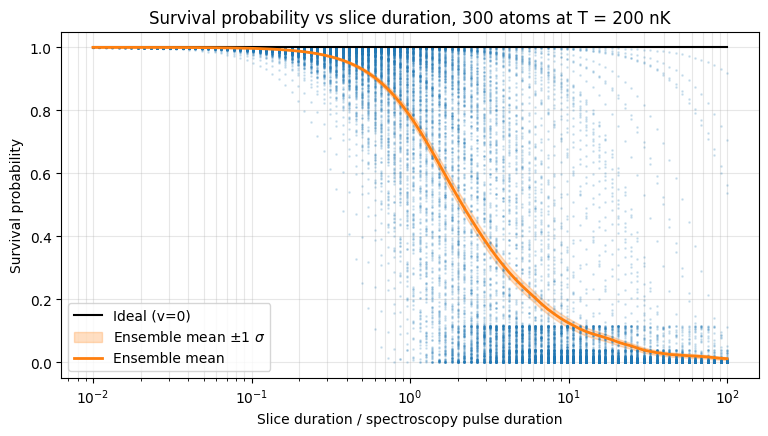

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for trace in survival_traces:
    ax.plot(
        slice_durations_over_spectroscopy,
        trace,
        color="tab:blue",
        alpha=0.15,
        linestyle="",
        marker=".",
        markersize=2,
    )

sem_survival = std_survival / np.sqrt(N_ATOMS)

ax.plot(
    slice_durations_over_spectroscopy,
    ideal_survival,
    color="black",
    lw=1.5,
    label="Ideal (v=0)",
)
ax.fill_between(
    slice_durations_over_spectroscopy,
    mean_survival - sem_survival,
    mean_survival + sem_survival,
    color="tab:orange",
    alpha=0.25,
    label=r"Ensemble mean $\pm 1$ $\sigma$",
)
ax.plot(
    slice_durations_over_spectroscopy,
    mean_survival,
    color="tab:orange",
    lw=2.0,
    label="Ensemble mean",
)

ax.set_xscale("log")
ax.set_xlabel(r"Slice duration / spectroscopy pulse duration")
ax.set_ylabel("Survival probability")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3, which="both")
ax.legend()
ax.set_title(
    rf"Survival probability vs slice duration, {N_ATOMS} atoms at T = {TEMPERATURE * 1e9:.0f} nK"
)


vs.tag_plot(small=True)
